# Week 8 Exercises — Report

**Course:** Data-Driven Methods  
**Author:** Dimitris Papantzikos  
**Date:** May 21, 2026

---

## Abstract
This notebook reproduces the DeepONet antiderivative benchmark from Lecture 6. The operator takes a sampled input function $v(x)$ and returns its antiderivative $u(x)=nt_0^x v(s)ds$. A DeepONet with separate branch and trunk networks is trained on the aligned benchmark data from DeepXDE and evaluated on held-out function samples.

# Exercise 6.1 — DeepONet approximation of the antiderivative operator

## Problem Statement
Reproduce the results of approximating the antiderivative operator with a DeepONet similar to the one presented in the lecture slides. Given a sampled function $v$ on 100 sensor points and a coordinate $x$, predict $G(v)(x)=nt_0^x v(s)ds$.

## Approach / Method
- Use the aligned DeepXDE benchmark data provided with the exercise.
- Train a DeepONet with two hidden layers of width 48 in both the branch and trunk networks.
- Optimise with Adam and an MSE loss on all function-coordinate pairs.
- Evaluate the test MSE and visualise one representative prediction.

## Results
The trained model reaches a test MSE on the order of $10^{-4}$ on this dataset.

## Discussion
This benchmark is a direct demonstration that operator learning can approximate a family of antiderivative maps more naturally than fitting each function independently.

In [1]:
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

plt.rcParams["figure.dpi"] = 120

seed = 28
torch.manual_seed(seed)
np.random.seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print(f"Device: {device}")

def to_tensor(arr):
    return torch.tensor(arr, dtype=torch.float32, device=device)

def to_numpy(arr):
    return arr.detach().cpu().numpy()

Device: mps


In [2]:
data_dir = Path("data/deeponet_antiderivative_aligned")
train_data = np.load(data_dir / "antiderivative_aligned_train.npz", allow_pickle=True)
test_data = np.load(data_dir / "antiderivative_aligned_test.npz", allow_pickle=True)

X_train = (to_tensor(train_data["X"][0]), to_tensor(train_data["X"][1]))
y_train = to_tensor(train_data["y"])

X_test = (to_tensor(test_data["X"][0]), to_tensor(test_data["X"][1]))
y_test = to_tensor(test_data["y"])

n_train_functions, n_points = y_train.shape
n_test_functions = y_test.shape[0]

print("Training data shapes:")
print("  Branch input:", X_train[0].shape)
print("  Trunk input: " , X_train[1].shape)
print("  Output:      " , y_train.shape)

print("\nTest data shapes:")
print("  Branch input:", X_test[0].shape)
print("  Trunk input: " , X_test[1].shape)
print("  Output:      " , y_test.shape)

Training data shapes:
  Branch input: torch.Size([150, 100])
  Trunk input:  torch.Size([100, 1])
  Output:       torch.Size([150, 100])

Test data shapes:
  Branch input: torch.Size([1000, 100])
  Trunk input:  torch.Size([100, 1])
  Output:       torch.Size([1000, 100])


In [3]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=48, output_dim=40, final_tanh=False):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim),
        )
        self.final_tanh = final_tanh
        self.final_activation = nn.Tanh()

        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_normal_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        x = self.net(x)
        if self.final_tanh:
            x = self.final_activation(x)
        return x


class DeepONet(nn.Module):
    def __init__(self, branch_dim, trunk_dim, hidden_dim=48, latent_dim=40):
        super().__init__()
        self.branch = MLP(branch_dim, hidden_dim, latent_dim, final_tanh=False)
        self.trunk = MLP(trunk_dim, hidden_dim, latent_dim, final_tanh=True)

    def forward(self, branch_input, trunk_input):
        branch_features = self.branch(branch_input)
        trunk_features = self.trunk(trunk_input)
        return torch.sum(branch_features * trunk_features, dim=-1)


model = DeepONet(branch_dim=X_train[0].shape[1], trunk_dim=X_train[1].shape[1]).to(device)
loss_fn = nn.MSELoss()

In [4]:
train_branch = X_train[0].repeat_interleave(n_points, dim=0)
train_trunk = X_train[1].repeat(n_train_functions, 1)
train_target = y_train.reshape(-1)

epochs = 1000
learning_rate = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
loss_history = []

start_time = time.perf_counter()
model.train()

for epoch in range(epochs):
    prediction = model(train_branch, train_trunk)
    loss = loss_fn(prediction, train_target)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if (epoch + 1) % 200 == 0:
        print(f"Epoch {epoch + 1:4d}: train loss = {loss.item():.3e}")

training_time = time.perf_counter() - start_time
print(f"Training time: {training_time:.1f} seconds")

Epoch  200: train loss = 3.093e-03
Epoch  400: train loss = 6.145e-04
Epoch  600: train loss = 5.216e-04
Epoch  800: train loss = 1.790e-03
Epoch 1000: train loss = 4.091e-04
Training time: 6.7 seconds


In [5]:
model.eval()

test_branch = X_test[0].repeat_interleave(n_points, dim=0)
test_trunk = X_test[1].repeat(n_test_functions, 1)
test_target = y_test.reshape(-1)

with torch.no_grad():
    test_prediction = model(test_branch, test_trunk)
    test_mse = loss_fn(test_prediction, test_target).item()

test_prediction_matrix = test_prediction.reshape(y_test.shape)
print(f"Test MSE: {test_mse:.3e}")

Test MSE: 7.343e-04


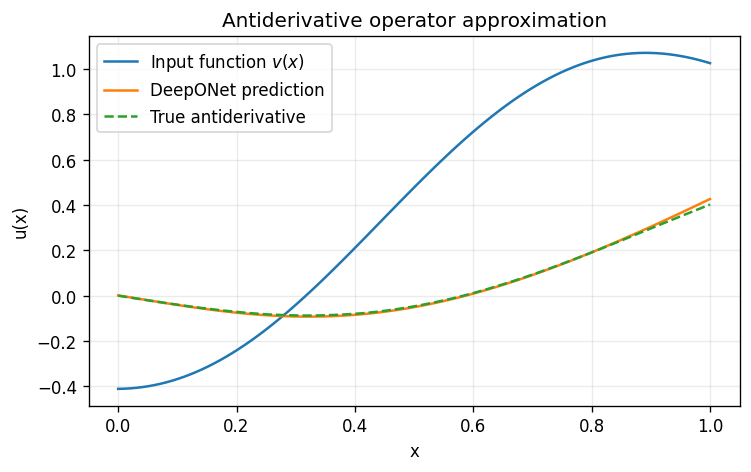

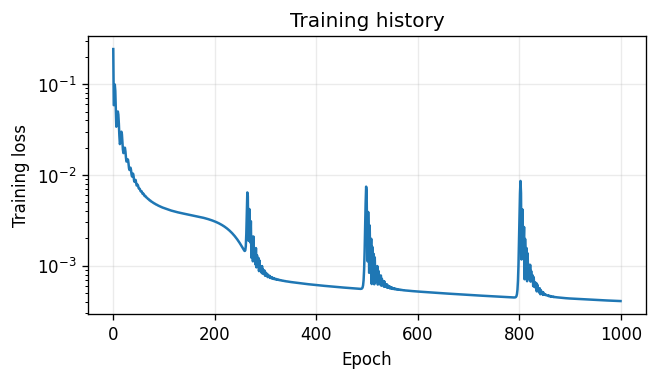

In [6]:
idx = 100
x_grid = to_numpy(X_test[1]).ravel()
input_function = to_numpy(X_test[0][idx])
prediction = to_numpy(test_prediction_matrix[idx])
truth = to_numpy(y_test[idx])

fig, ax = plt.subplots(1, 1, figsize=(7, 4))
ax.plot(x_grid, input_function, label="Input function $v(x)$")
ax.plot(x_grid, prediction, label="DeepONet prediction")
ax.plot(x_grid, truth, "--", label="True antiderivative")
ax.set_xlabel("x")
ax.set_ylabel("u(x)")
ax.set_title("Antiderivative operator approximation")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(6, 3))
ax.semilogy(loss_history)
ax.set_xlabel("Epoch")
ax.set_ylabel("Training loss")
ax.set_title("Training history")
ax.grid(True, alpha=0.25)
plt.show()